In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs

In [6]:
x,y = make_blobs(
    n_samples = 300,   # 一共生成300个样本点
    n_features = 2,    # 生成2维的数据
    centers = 3,       # 种类的数目
    cluster_std = 1,   # 类内标准差
    center_box = (-10, 10), # 范围
    random_state = 233, # 随机数种子
    return_centers = False # 增加类别中心点的返回值
    )

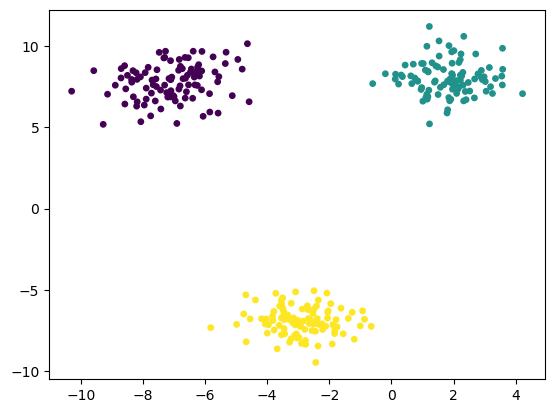

In [7]:
plt.scatter(x[:,0],x[:,1],c=y,s=15)

#### **划分数据集**

In [9]:
# 随机打乱数据的顺序
index = np.arange(20)
index

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [15]:
# 方法一：打乱已有数组
np.random.shuffle(index)
index

array([ 5,  3,  1, 15, 18,  2, 11, 10, 19,  4,  0, 12, 17,  8, 13,  9,  7,
       14, 16,  6])

In [16]:
# 方法二：生成乱序
np.random.permutation(20)

array([12,  8,  2, 13,  1,  9, 14, 16,  4, 11,  7,  0, 17,  6, 18, 15, 19,
        3,  5, 10], dtype=int32)

In [18]:
np.random.seed(233)
shuffle = np.random.permutation(len(x))
shuffle

array([ 23,  86, 204, 287, 206, 170, 234,  94, 146, 180, 263,  22,   3,
       264, 194, 290, 229, 177, 208, 202,  10, 188, 262, 120, 148, 121,
        98, 160, 267, 136, 294,   2,  34, 142, 271, 133, 127,  12,  29,
        49, 112, 218,  36,  57,  45,  11,  25, 151, 212, 289, 157,  19,
       275, 176, 144,  82, 161,  77,  51, 152, 135,  16,  65, 189, 298,
       279,  37, 187,  44, 210, 178, 165,   6, 162,  66,  32, 198,  43,
       108, 211,  67, 119, 284,  90,  89,  56, 217, 158, 228, 248, 191,
        47, 296, 123, 181, 200,  40,  87, 232,  97, 113, 122, 220, 153,
       173,  68,  99,  61, 273, 269, 281, 209,   4, 110, 259,  95, 205,
       288,   8, 283, 231, 291, 171, 111, 242, 216, 285,  54, 100,  38,
       185, 235, 174, 201, 107, 223, 222, 196, 268, 114, 147, 166,  85,
        39,  58, 256, 258,  74, 251,  15, 150, 137,  70,  91,  52,  14,
       169,  21, 184, 207, 238, 128, 219, 125, 293, 134,  27, 265,  96,
       270,  18, 109, 126, 203,  88, 249,  92, 213,  60, 227,   

In [21]:
shuffle.shape

(300,)

In [22]:
train_size = 0.7
train_index = shuffle[:int(len(x)*train_size)]
test_index = shuffle[int(len(x)*train_size):]
train_index,test_index

(array([ 23,  86, 204, 287, 206, 170, 234,  94, 146, 180, 263,  22,   3,
        264, 194, 290, 229, 177, 208, 202,  10, 188, 262, 120, 148, 121,
         98, 160, 267, 136, 294,   2,  34, 142, 271, 133, 127,  12,  29,
         49, 112, 218,  36,  57,  45,  11,  25, 151, 212, 289, 157,  19,
        275, 176, 144,  82, 161,  77,  51, 152, 135,  16,  65, 189, 298,
        279,  37, 187,  44, 210, 178, 165,   6, 162,  66,  32, 198,  43,
        108, 211,  67, 119, 284,  90,  89,  56, 217, 158, 228, 248, 191,
         47, 296, 123, 181, 200,  40,  87, 232,  97, 113, 122, 220, 153,
        173,  68,  99,  61, 273, 269, 281, 209,   4, 110, 259,  95, 205,
        288,   8, 283, 231, 291, 171, 111, 242, 216, 285,  54, 100,  38,
        185, 235, 174, 201, 107, 223, 222, 196, 268, 114, 147, 166,  85,
         39,  58, 256, 258,  74, 251,  15, 150, 137,  70,  91,  52,  14,
        169,  21, 184, 207, 238, 128, 219, 125, 293, 134,  27, 265,  96,
        270,  18, 109, 126, 203,  88, 249,  92, 213

In [25]:
train_index.shape,test_index.shape

((210,), (90,))

In [27]:
x[train_index].shape,y[train_index].shape

((210, 2), (210,))

In [32]:
def my_train_test_split(x,y, train_size = 0.7, random_state = None):
    if random_state:
        np.random.seed(random_state)
    shuffle = np.random.permutation(len(x))
    train_index=shuffle[:int(len(x) * train_size)]
    test_index = shuffle[int(len(x) * train_size):]
    return x[train_index], x[test_index],y[train_index],y[test_index]

In [37]:
x_train,x_test,y_train,y_test = my_train_test_split(x,y,train_size = 0.7, random_state = 233)

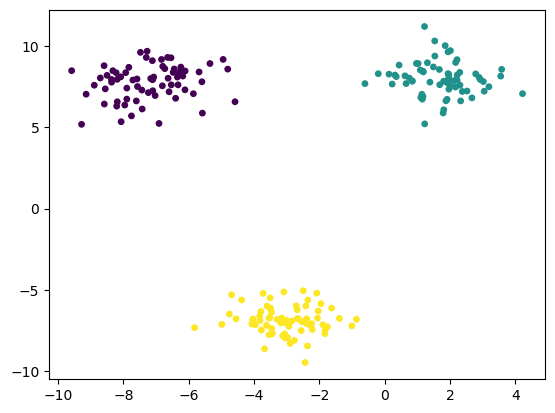

In [44]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_train,s=15)
plt.show()

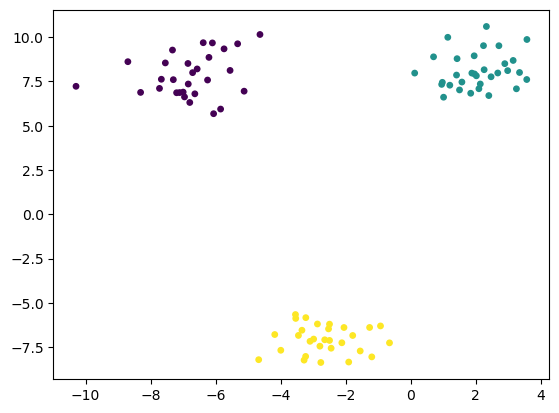

In [45]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test,s=15)
plt.show()

#### **sklearn划分数据集**

In [47]:
from sklearn.model_selection import train_test_split

In [50]:
# 使用sklearn库中的train_test_split方法直接生成训练集和测试集
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, random_state=233)

In [51]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((210, 2), (90, 2), (210,), (90,))

In [52]:
# 查看标签y是否也是正常分的
from collections import Counter
Counter(y_train),Counter(y_test)

(Counter({np.int64(0): 75, np.int64(1): 69, np.int64(2): 66}),
 Counter({np.int64(2): 34, np.int64(1): 31, np.int64(0): 25}))

In [53]:
# train_test_split方法，将标签y作为参数stratify，可以按比例划分标签
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, random_state=233,stratify=y)
Counter(y_train),Counter(y_test)

(Counter({np.int64(0): 70, np.int64(2): 70, np.int64(1): 70}),
 Counter({np.int64(2): 30, np.int64(0): 30, np.int64(1): 30}))

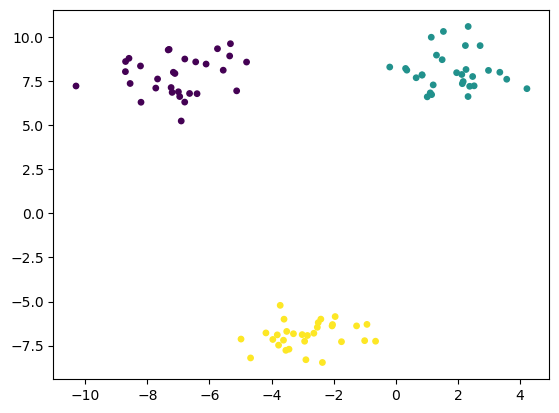

In [54]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test,s=15)
plt.show()

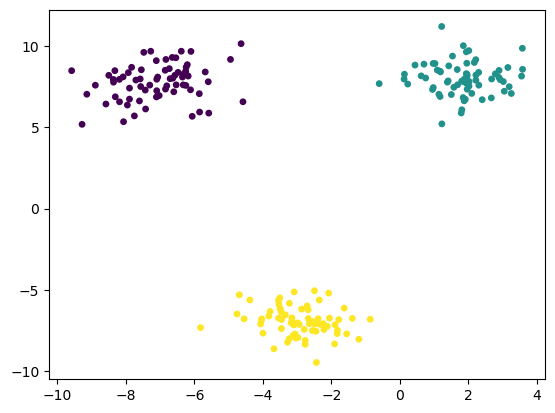

In [55]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_train,s=15)
plt.show()